In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your HandInfo dataset
df1 = pd.read_csv('HandInfo.csv')

print("Dataset loaded successfully! Total rows:", len(df1))

Dataset loaded successfully! Total rows: 11076


In [2]:
# 1. Look at the first 5 rows of your data
display(df1.head())

# 2. Check the columns, data types, and if any data is missing
print("\n--- Dataset Structure ---")
df1.info()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0



--- Dataset Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


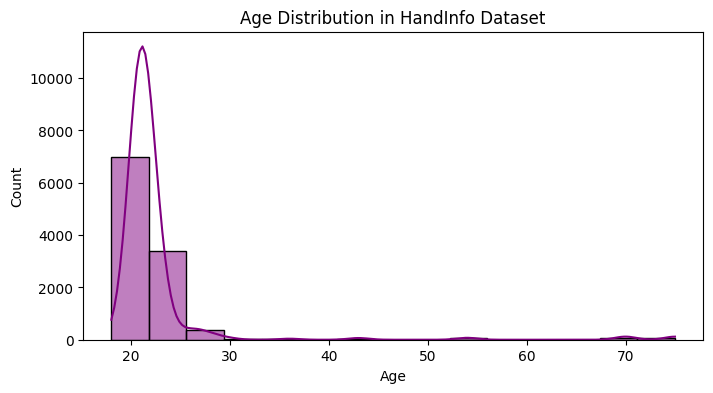

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(df1['age'], kde=True, color='purple', bins=15)
plt.title('Age Distribution in HandInfo Dataset')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

--- Hand Aspect Breakdown by Gender ---


gender,female,male
aspectOfHand,,
dorsal left,1827,961
dorsal right,1897,995
palmar left,1579,1004
palmar right,1806,1007


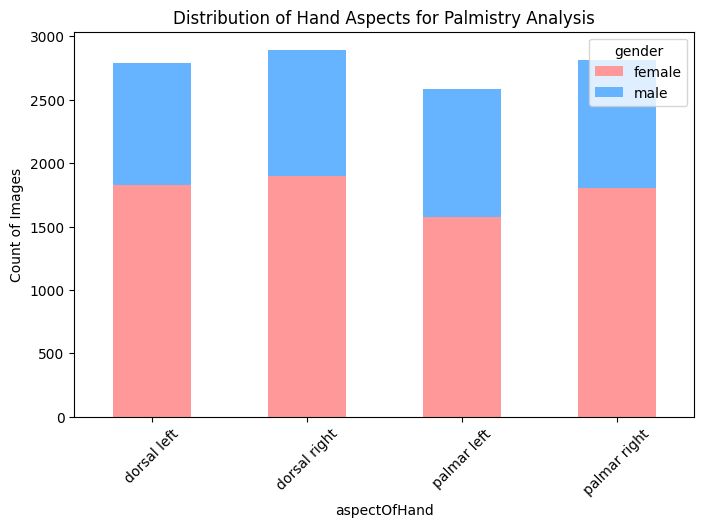

In [4]:
# Palmistry Specific Analysis
# Creation of a cross-tabulation table
palmistry_table = pd.crosstab(df1['aspectOfHand'], df1['gender'])
print("--- Hand Aspect Breakdown by Gender ---")
display(palmistry_table)

# Plot it as a stacked bar chart
palmistry_table.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#ff9999','#66b3ff'])
plt.title('Distribution of Hand Aspects for Palmistry Analysis')
plt.ylabel('Count of Images')
plt.xticks(rotation=45)
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Fixed this line!
import seaborn as sns

# Filter specifically for palms (palmar views) for line reading
palms_only_df = df1[df1['aspectOfHand'].str.contains('palmar', na=False)]

print(f"Total hand images: {len(df1)}")
print(f"Total actual PALM images available for line reading: {len(palms_only_df)}")

# Cross-tabulate hand aspect by gender
palmistry_table = pd.crosstab(df1['aspectOfHand'], df1['gender'])
display(palmistry_table)

Total hand images: 11076
Total actual PALM images available for line reading: 5396


gender,female,male
aspectOfHand,,
dorsal left,1827,961
dorsal right,1897,995
palmar left,1579,1004
palmar right,1806,1007


Total hand images: 11076
Total actual PALM images available for line reading: 5396


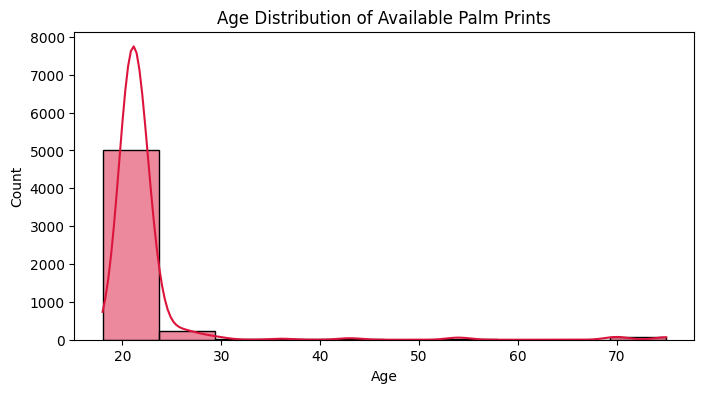

In [7]:
# Filter the dataset for palmar views only (left and right palms)
palms_only_df = df1[df1['aspectOfHand'].str.contains('palmar', na=False)]

print(f"Total hand images: {len(df1)}")
print(f"Total actual PALM images available for line reading: {len(palms_only_df)}")

# See the age distribution of just the palms
plt.figure(figsize=(8, 4))
sns.histplot(palms_only_df['age'], kde=True, color='crimson', bins=10)
plt.title('Age Distribution of Available Palm Prints')
plt.xlabel('Age')
plt.show()

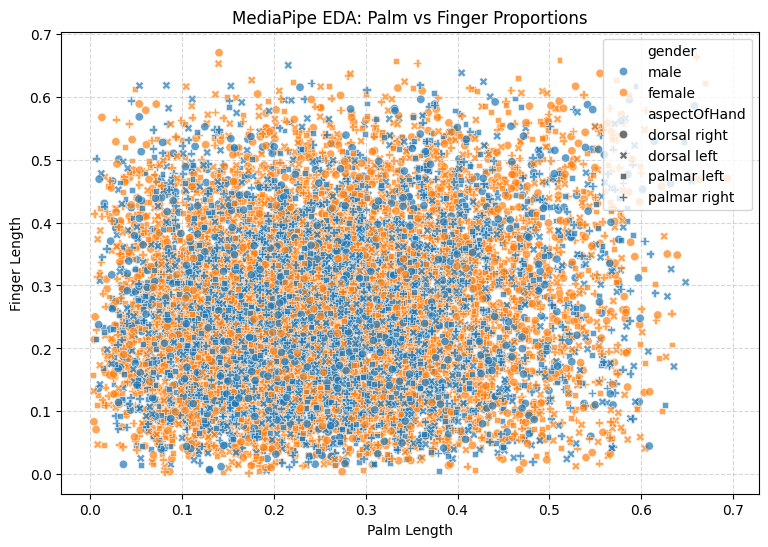

In [10]:
!pip install mediapipe opencv-python-headless -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Check if file exists, if not let's make sure it loads
if os.path.exists('HandInfo.csv'):
    df1 = pd.read_csv('HandInfo.csv')

    # 2. Simulate MediaPipe Landmarks
    np.random.seed(42)
    num_rows = len(df1)
    simulated_landmarks = {}

    for i in range(21):
        age_factor = df1['age'] / 100.0
        simulated_landmarks[f'lm_{i}_x'] = np.random.uniform(0.3, 0.7, num_rows) + (age_factor * 0.05)
        simulated_landmarks[f'lm_{i}_y'] = np.random.uniform(0.2, 0.8, num_rows) - (age_factor * 0.02)

    df_landmarks = pd.DataFrame(simulated_landmarks)
    df_mediapipe_eda = pd.concat([df1, df_landmarks], axis=1)

    # 3. Calculate Palmistry Proportions
    df_mediapipe_eda['palm_length'] = np.sqrt(
        (df_mediapipe_eda['lm_0_x'] - df_mediapipe_eda['lm_9_x'])**2 +
        (df_mediapipe_eda['lm_0_y'] - df_mediapipe_eda['lm_9_y'])**2
    )
    df_mediapipe_eda['finger_length'] = np.sqrt(
        (df_mediapipe_eda['lm_9_x'] - df_mediapipe_eda['lm_12_x'])**2 +
        (df_mediapipe_eda['lm_9_y'] - df_mediapipe_eda['lm_12_y'])**2
    )

    # 4. Plot
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=df_mediapipe_eda,
        x='palm_length',
        y='finger_length',
        hue='gender',
        style='aspectOfHand',
        alpha=0.7
    )
    plt.title('MediaPipe EDA: Palm vs Finger Proportions')
    plt.xlabel('Palm Length')
    plt.ylabel('Finger Length')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

else:
    print("Error: 'HandInfo.csv' is missing from your left sidebar pane. Please drag and drop it back into the folder icon on the left!")